# BM25 vs Dense 임베딩 기반 검색과 RRF 결합 성능 비교
> 서로 다른 검색방법의 결과가 상이할때 유용한 방법이다.

Reciprocal Rank Fusion(RRF)은 **여러 검색 결과의 순위를 합쳐서 하나의 최종 순위를 만드는 방법**이다.  
예를 들어, 키워드 검색 결과와 벡터 검색 결과처럼 서로 다른 방식으로 나온 문서 리스트가 있을 때, 각 문서가 각 리스트에서 몇 번째에 있는지(순위)를 이용해 점수를 매긴다.  

$$
\text{score}(d) = \sum_{q} \frac{1}{k + \text{rank}(q, d)}
$$

- $d$: 문서  
- $q$: 각 검색 결과 집합  
- $\text{rank}(q, d)$: 검색 결과 $q$에서 문서 $d$의 순위(1부터 시작)  
- $k$: 보통 60 정도로 쓰는 상수

즉, **여러 검색 결과에서 상위에 자주 등장하는 문서일수록 점수가 높아지고, 최종 순위에서 위로 올라간다**.  
이 방식은 각 검색 결과의 점수 범위가 달라도 상관없이, 순위만으로 융합하므로 간단하게 적용할 수 있다.

### 기본 환경변수 설정

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

### 데이터 읽어오기

In [3]:
import pandas as pd
from kiwipiepy import Kiwi # Kiwi 형태소 분석기

kiwi = Kiwi()

document_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')


### BM25 키워드 서치

In [4]:
# BM25 키워드 검색 모델
# - 문서를 토큰화해서 BM25 모델 생성
# - 검색어도 동일하게 토큰화하여 BM25 검색시 활용

from rank_bm25 import BM25Okapi
from kiwipiepy import Kiwi

# Kiwi로 문장을 형태소 단위로 토큰화하는 함수
def kiwi_tokenize(doc):
    return [token.form for token in kiwi.tokenize(doc)]

# 문서 내용 토큰화
tokenized_docs = [kiwi_tokenize(doc) for doc in document_df['content']]
bm25 = BM25Okapi(tokenized_docs) # BM25 모델 생성 (토큰화된 문서)

# 질의문을 토큰화해서 BM25로 상위 문서 검색하는 함수
def bm25_search(query, top_k =5):
    query_tokens = kiwi_tokenize(query)         # 검색어 토큰화
    scores = bm25.get_scores(query_tokens)    # 각 문서의 BM25 점수 계산  

    # 점수 기준 내림차순 정렬한 인덱스
    ranked_idx = sorted(range(len(scores)), key = lambda i: scores[i], reverse= True)
    # 상위 top_k개의 doc_id 리스트
    retrieved_docs = [document_df['doc_id'].iloc[i] for i in ranked_idx[:top_k]]
    return retrieved_docs

bm25_search('제주도 관광 명소')

['D1', 'D2', 'D3', 'D4', 'D5']

### Pinecone 백터스토어 연결

In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

# 1536차원 임베딩 모델
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small') 

 # 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir',      # 연결할 index명
    embedding=embeddings,   # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩차원이 같아야 함)
)

### 평가지표 계산

In [7]:
import numpy as np

def parse_relevant(relevant_str) -> dict[str, int]:
    """
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1 :3', 'D4' :1, 'D30':1} 
    """

    pairs = relevant_str.split(';') # ';' 기준으로 분리
    rel_dict = {}           # {doc_id : grade, ...}
    for pair in pairs:
        doc_id, grade = pair.split('=')    # '=' 기준으로 분리
        rel_dict[doc_id] = int(grade)   # {doc_id : grade, ...}
    return rel_dict

In [6]:
# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict]) # top-k 적중 개수
    precision = hits / k # 정밀도 = 맞춘갯수 / 전체갯수

    # Recall@k
    total_relevant = len(relevant_dict) # 전체 관려 문서 수
    # 재현률 = 관련 문서 맞춘 수
    recall = hits / total_relevant if total_relevant > 0 else 0 

    # MRR 예측치 중 첫 관련문서 순위 점수
    rr = 0 # 관련 문서 수
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1) # 첫 적중 순위 역수
            break # 첫 번째 적중 rr 반영 후 나감
    
    # AP (MAP를 위한 사전 계산)
    num_correct = 0     # 현재까지의 적중 횟수
    precisions = []     # 적중시의 precision
    for idx, doc in enumerate(predicted[:k]): # top-k 범위에서
        if doc in relevant_dict:
            num_correct +=1     # 적중시 1 누적
            precisions.append(num_correct/(idx+1)) # 현재 시점의 precision 기록
    # pricision 평균치 사용, 없으면 0
    ap = np.mean(precisions) if precisions else 0 

    return precision, recall, rr, ap            

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], [] # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid= row['query_id'] # 쿼리 ID
        # 정답 dict 파싱
        relevant_dict = parse_relevant(row['relevant_doc_ids']) 
        predicted = method_results[qid] # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k) # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return {
        'P@k' : np.mean(prec_list), # 쿼리 평균 Precision@k
        'R@k' : np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR' : np.mean(rr_list),   # 쿼리 평균 MRR
        'MAP' : np.mean(ap_list),   # 쿼리 평균 MAP
    }

## 06.BM25와 Dense 결과의 RRF 결합

> bm25와 dense 검색의 결과가 상이할대 rrf는 빛을 발한다.

RRF(Reciprocal Rank Fusion)는 서로 다른 검색 기법의 결과를 하나로 합쳐 더 안정적이고 정확한 순위를 만들어 내는 간단한 랭크 결합 기법이다.

1. 여러 검색 결과 리스트(예: BM25, Dense)에서 **문서의 순위(rank)** 를 이용해 점수를 계산한다.
2. 각 리스트별로, 문서가 n위에 있을 때 주어지는 점수는
   $\displaystyle \frac{1}{k + n}$
   형태이다. 여기서 k는 보통 60처럼 비교적 큰 상수로, 순위 차이에 따른 점수 차이를 완만하게 만들어 준다.
3. 두 개 이상의 리스트에서 **나온 점수를 모두 더해** 최종 RRF-점수를 구한다.
4. 최종 점수가 높은 문서일수록 “여러 기법에서 꾸준히 상위권” 에 올랐다는 뜻이므로, 가장 관련성이 높다고 판단된다.

예를 들어, 문서 A가

* BM25 결과에서 2위 → 점수 1/(60+2)
* Dense 결과에서 5위 → 점수 1/(60+5)
  를 받았다면,

$$
\text{RRF-점수}(A) = \frac{1}{62} + \frac{1}{65}
$$

가 되어, 두 기법에서 모두 좋은 순위를 받은 문서 A가 최종적으로 높은 순위에 오르게 된다.

이처럼 RRF는 각 검색 기법의 강점을 살려 **서로 다른 결과를 보완**하며, 한쪽에서만 높은 점수를 받은 노이즈 문서를 걸러내고, 여러 기법에서 상위권에 오른 핵심 문서를 잘 찾아준다.

## BM25 | Vector 검색 수행

In [8]:
bm25_results = {}           # qid별 BM25 검색 결과 저장 dict
for idx, row in queries_df.iterrows(): 
    qid = row['query_id'] # 쿼리 ID 추출
    query_text = row['query_text'] # 쿼리 문장
    bm25_results[qid] = bm25_search(query_text, top_k=5) # {qid : query_text 와 가장 가까운 5개의 doc_id}

bm25_results    

{'Q1': ['D1', 'D2', 'D3', 'D4', 'D5'],
 'Q2': ['D13', 'D2', 'D1', 'D3', 'D4'],
 'Q3': ['D2', 'D21', 'D14', 'D11', 'D28'],
 'Q4': ['D4', 'D9', 'D1', 'D30', 'D5'],
 'Q5': ['D5', 'D18', 'D19', 'D23', 'D15'],
 'Q6': ['D6', 'D27', 'D17', 'D25', 'D3'],
 'Q7': ['D27', 'D25', 'D7', 'D14', 'D9'],
 'Q8': ['D8', 'D18', 'D30', 'D12', 'D29'],
 'Q9': ['D9', 'D27', 'D1', 'D2', 'D3'],
 'Q10': ['D10', 'D3', 'D17', 'D9', 'D25'],
 'Q11': ['D11', 'D4', 'D14', 'D28', 'D26'],
 'Q12': ['D12', 'D8', 'D9', 'D27', 'D5'],
 'Q13': ['D13', 'D14', 'D26', 'D2', 'D3'],
 'Q14': ['D14', 'D7', 'D25', 'D27', 'D26'],
 'Q15': ['D9', 'D15', 'D26', 'D14', 'D1'],
 'Q16': ['D16', 'D15', 'D9', 'D29', 'D8'],
 'Q17': ['D17', 'D25', 'D6', 'D3', 'D10'],
 'Q18': ['D18', 'D4', 'D28', 'D5', 'D7'],
 'Q19': ['D19', 'D18', 'D14', 'D24', 'D29'],
 'Q20': ['D20', 'D27', 'D10', 'D3', 'D4'],
 'Q21': ['D21', 'D19', 'D25', 'D2', 'D11'],
 'Q22': ['D22', 'D23', 'D19', 'D18', 'D24'],
 'Q23': ['D23', 'D26', 'D24', 'D22', 'D19'],
 'Q24': ['D24', 'D2

In [9]:
# Vector Store 검색 결과를 쿼리별로 수집
dense_results = {}           # qid별 Dense 검색 결과 저장 dict
for idx, row in queries_df.iterrows(): 
    qid = row['query_id']           # 쿼리 ID 추출
    query_text = row['query_text']  # 쿼리 문장
    # {qid : query_text 와 가장 가까운 5개의 doc_id}
    docs = vector_store.similarity_search(query_text, top_k=5) # 벡터 유사도 기준 top-5 문서 검색
    # doc_id만 리스트로 저장
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs] 
dense_results

{'Q1': ['D12', 'D1', 'D13', 'D8'],
 'Q2': ['D13', 'D2', 'D12', 'D24'],
 'Q3': ['D3', 'D17', 'D15', 'D18'],
 'Q4': ['D4', 'D16', 'D26', 'D15'],
 'Q5': ['D5', 'D23', 'D7', 'D14'],
 'Q6': ['D6', 'D14', 'D25', 'D13'],
 'Q7': ['D25', 'D7', 'D29', 'D14'],
 'Q8': ['D8', 'D12', 'D18', 'D30'],
 'Q9': ['D9', 'D3', 'D19', 'D15'],
 'Q10': ['D10', 'D25', 'D4', 'D15'],
 'Q11': ['D11', 'D18', 'D19', 'D12'],
 'Q12': ['D12', 'D8', 'D1', 'D13'],
 'Q13': ['D13', 'D2', 'D19', 'D24'],
 'Q14': ['D14', 'D6', 'D26', 'D25'],
 'Q15': ['D15', 'D14', 'D9', 'D11'],
 'Q16': ['D16', 'D23', 'D9', 'D19'],
 'Q17': ['D17', 'D25', 'D15', 'D10'],
 'Q18': ['D18', 'D4', 'D27', 'D14'],
 'Q19': ['D19', 'D18', 'D27', 'D24'],
 'Q20': ['D20', 'D19', 'D22', 'D24'],
 'Q21': ['D21', 'D23', 'D18', 'D24'],
 'Q22': ['D22', 'D23', 'D24', 'D19'],
 'Q23': ['D23', 'D24', 'D22', 'D20'],
 'Q24': ['D23', 'D24', 'D22', 'D19'],
 'Q25': ['D25', 'D7', 'D17', 'D20'],
 'Q26': ['D26', 'D14', 'D7', 'D27'],
 'Q27': ['D27', 'D29', 'D30', 'D28'],
 'Q28

In [ ]:
# BM25 + Dense 결과를 RRF로 결합해서 Hybrid 랭킹 생성

def rrf_rank(bm25_list, dense_list, k=60):
    candidate_scores = {} # 문서별 RRF 점수 누적 dict
    for rank, doc in enumerate(bm25_list, 1):
        # BM25 리스트에서 RRF 점수 누적 
        candidate_scores[doc] = candidate_scores.get(doc, 0) + 1 / (k + rank)
    for rank, doc in enumerate(dense_list, 1):
        # Dense 리스트에서 RRF 점수 누적
        candidate_scores[doc] = candidate_scores.get(doc, 0) + 1 / (k + rank)

    # (doc_id, 값) 일 때 누적된 값을 기준으로 내림차순 정렬
    ranked = sorted(candidate_scores.items(), key=lambda item:item[1], reverse=True)
    return [doc for doc, _ in ranked] # doc_id만 반환

rrf_results = {} # qid별 RRF 결합 결과 저장 dict
top_k = 5

for idx, row in queries_df.iterrows():  # query_df 행별로 순회
    qid = row['query_id']
    query_text = row['query_text']
    bm25_top20 = bm25_results[qid]      # BM25 결과
    dense_top20 = dense_results[qid]    # Dense 결과
    rrf_list = rrf_rank(bm25_top20, dense_top20)
    rrf_results[qid] = rrf_list[:top_k] # 상위 top_k 개만 저장
rrf_results


{'Q1': ['D1', 'D12', 'D2', 'D3', 'D13'],
 'Q2': ['D13', 'D2', 'D1', 'D12', 'D3'],
 'Q3': ['D2', 'D3', 'D21', 'D17', 'D14'],
 'Q4': ['D4', 'D9', 'D16', 'D1', 'D26'],
 'Q5': ['D5', 'D23', 'D18', 'D19', 'D7'],
 'Q6': ['D6', 'D25', 'D27', 'D14', 'D17'],
 'Q7': ['D25', 'D7', 'D14', 'D27', 'D29'],
 'Q8': ['D8', 'D18', 'D12', 'D30', 'D29'],
 'Q9': ['D9', 'D3', 'D27', 'D1', 'D19'],
 'Q10': ['D10', 'D25', 'D3', 'D17', 'D4'],
 'Q11': ['D11', 'D4', 'D18', 'D14', 'D19'],
 'Q12': ['D12', 'D8', 'D9', 'D1', 'D27'],
 'Q13': ['D13', 'D2', 'D14', 'D26', 'D19'],
 'Q14': ['D14', 'D25', 'D26', 'D7', 'D6'],
 'Q15': ['D15', 'D9', 'D14', 'D26', 'D11'],
 'Q16': ['D16', 'D9', 'D15', 'D23', 'D29'],
 'Q17': ['D17', 'D25', 'D10', 'D6', 'D15'],
 'Q18': ['D18', 'D4', 'D28', 'D27', 'D5'],
 'Q19': ['D19', 'D18', 'D24', 'D14', 'D27'],
 'Q20': ['D20', 'D27', 'D19', 'D10', 'D22'],
 'Q21': ['D21', 'D19', 'D23', 'D25', 'D18'],
 'Q22': ['D22', 'D23', 'D19', 'D24', 'D18'],
 'Q23': ['D23', 'D24', 'D22', 'D26', 'D20'],
 'Q24':

In [11]:
# 데이터 프레임으로 시각화

import pandas as pd

# 컬럼이 많아도 잘리지 않고 표시
pd.set_option('display.max_columns', None) 
pd.DataFrame(bm25_results, columns = bm25_results.keys())


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30
0,D1,D13,D2,D4,D5,D6,D27,D8,D9,D10,D11,D12,D13,D14,D9,D16,D17,D18,D19,D20,D21,D22,D23,D24,D25,D26,D27,D28,D29,D30
1,D2,D2,D21,D9,D18,D27,D25,D18,D27,D3,D4,D8,D14,D7,D15,D15,D25,D4,D18,D27,D19,D23,D26,D23,D9,D14,D30,D27,D12,D4
2,D3,D1,D14,D1,D19,D17,D7,D30,D1,D17,D14,D9,D26,D25,D26,D9,D6,D28,D14,D10,D25,D19,D24,D22,D17,D7,D1,D30,D22,D29
3,D4,D3,D11,D30,D23,D25,D14,D12,D2,D9,D28,D27,D2,D27,D14,D29,D3,D5,D24,D3,D2,D18,D22,D19,D3,D5,D2,D1,D28,D25
4,D5,D4,D28,D5,D15,D3,D9,D29,D3,D25,D26,D5,D3,D26,D1,D8,D10,D7,D29,D4,D11,D24,D19,D3,D8,D29,D3,D2,D30,D14


In [13]:
pd.DataFrame(rrf_results, columns=rrf_results.keys())

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30
0,D1,D13,D2,D4,D5,D6,D25,D8,D9,D10,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20,D21,D22,D23,D24,D25,D26,D27,D28,D29,D4
1,D12,D2,D3,D9,D23,D25,D7,D18,D3,D25,D4,D8,D2,D25,D9,D9,D25,D4,D18,D27,D19,D23,D24,D23,D17,D14,D30,D30,D30,D30
2,D2,D1,D21,D16,D18,D27,D14,D12,D27,D3,D18,D9,D14,D26,D14,D15,D10,D28,D24,D19,D23,D19,D22,D22,D9,D7,D29,D27,D12,D14
3,D3,D12,D17,D1,D19,D14,D27,D30,D1,D17,D14,D1,D26,D7,D26,D23,D6,D27,D14,D10,D25,D24,D26,D19,D7,D5,D1,D29,D22,D26
4,D13,D3,D14,D26,D7,D17,D29,D29,D19,D4,D19,D27,D19,D6,D11,D29,D15,D5,D27,D22,D18,D18,D20,D3,D3,D27,D2,D1,D27,D29


In [15]:
# BM25 / Dense 결과로 P@5, R@5, MRR, MAP 계산
bm25_metrics = evaluate_all(bm25_results, queries_df, k=5)
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
rrf_metrics = evaluate_all(rrf_results, queries_df, k=5)

In [16]:
metrics_df = pd.DataFrame({
    'Metrics' : ['P@5', 'R@5', 'MRR', 'MAP'], # 지표 이름
    'BM25': [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']],
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'RRF': [rrf_metrics['P@k'], rrf_metrics['R@k'], rrf_metrics['MRR'], rrf_metrics['MAP']]
})
metrics_df

,Metrics,BM25,Dense,RRF
0,P@5,0.233333,0.240000,0.240000
1,R@5,0.838889,0.877778,0.877778
2,MRR,0.900000,0.950000,0.966667
3,MAP,0.874444,0.930556,0.938889


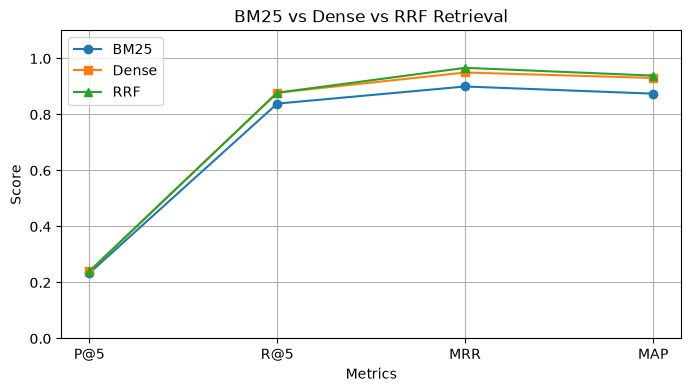

In [19]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
bm25_vals = [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']]
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
rrf_vals = [rrf_metrics['P@k'], rrf_metrics['R@k'], rrf_metrics['MRR'], rrf_metrics['MAP']]

x = range(len(metrics))

plt.figure(figsize=(8,4))
plt.plot(x, bm25_vals, marker='o', label='BM25')
plt.plot(x,dense_vals, marker='s', label='Dense')
plt.plot(x,rrf_vals, marker='^', label='RRF')
plt.xticks(x,metrics) # x축 눈금은 0~3 지표명
plt.ylim(0,1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('BM25 vs Dense vs RRF Retrieval')
plt.legend()
plt.grid()
plt.show()

### 지금 실험에서 Dense가 가장 높은 이유
##### 데이터셋 특성
- 쿼리: 자연어(의미 중심)
- 문서: 비교적 길고 서술형
- 정답 판단: 의미 유사성 중심
**Dense에게 매우 유리한 환경**

### RRF가 강해지는 조건
##### RRF는 이런 상황에서 좋다.
- BM25와 Dense가 서로 다른 문서를 잘 가져올 때
- Dense가 놓친 문서를 BM25가 보완해줄 때
- 쿼리가 짧고 키워드성이 강한 경우가 섞여 있을 때
**즉,두 모델의 오류 패턴이 다를 때**